# Week 7

### Lab 7.1

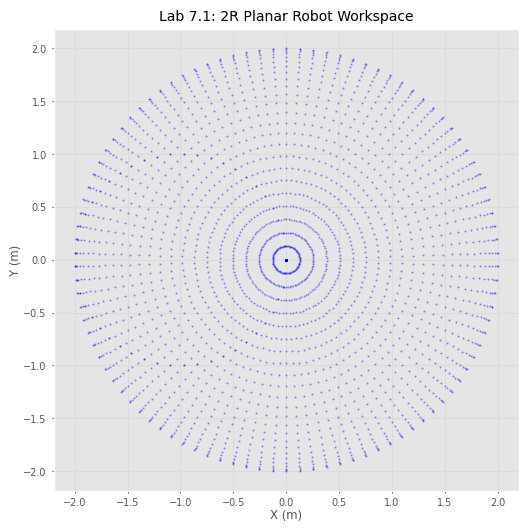

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb
from spatialmath import SE3

# Parameters
l1, l2 = 1.0, 1.0  # Link lengths
# --- 7.1: Manual FK Function & Workspace Plot ---
def manual_2r_fk(theta1, theta2):
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y

# Generate workspace scatter plot sweep
th1_range = np.linspace(-np.pi, np.pi, 50)
th2_range = np.linspace(-np.pi, np.pi, 50)

x_points, y_points = [], []
for t1 in th1_range:
    for t2 in th2_range:
        x, y = manual_2r_fk(t1, t2)
        x_points.append(x)
        y_points.append(y)

plt.figure(figsize=(6,6))
plt.scatter(x_points, y_points, s=1, c='blue', alpha=0.3)
plt.title("Lab 7.1: 2R Planar Robot Workspace")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.axis('equal')
plt.show()

### Lab 7.2

In [2]:
# --- 7.2: Toolbox Comparison ---
# Define the robot using DH parameters (Revolute joints along Z axis)
robot = rtb.DHRobot([
    rtb.RevoluteDH(a=l1),
    rtb.RevoluteDH(a=l2)
], name="Planar2R")

# Test configuration
test_q = [0.5, 0.785] # theta1, theta2 in radians
T_toolbox = robot.fkine(test_q)
x_man, y_man = manual_2r_fk(test_q[0], test_q[1])

print("--- Lab 7.2 Comparison Table ---")
print(f"Method     | X Coordinate | Y Coordinate")
print(f"-----------|--------------|--------------")
print(f"Manual     | {x_man:.4f}       | {y_man:.4f}")
print(f"Toolbox    | {T_toolbox.t[0]:.4f}       | {T_toolbox.t[1]:.4f}")

--- Lab 7.2 Comparison Table ---
Method     | X Coordinate | Y Coordinate
-----------|--------------|--------------
Manual     | 1.1595       | 1.4389
Toolbox    | 1.1595       | 1.4389


### Lab 7.3

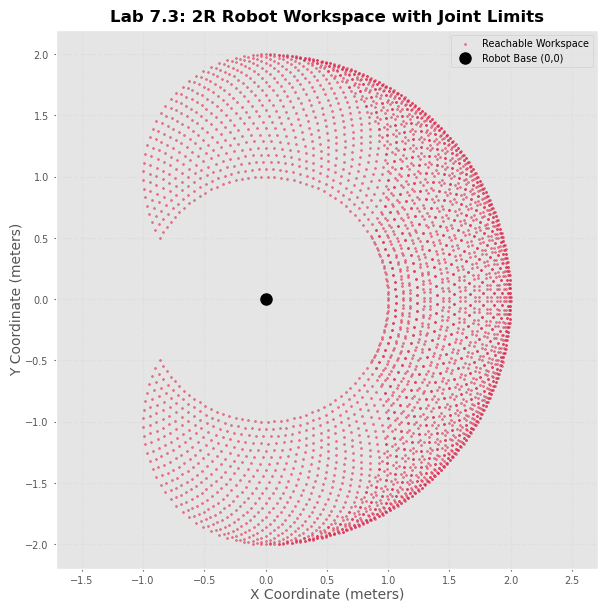

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Link lengths
l1, l2 = 1.0, 1.0  

# --- Define Joint Limits (in Radians) ---
# Joint 1 restricted to +/- 90 degrees (Forward hemisphere)
th1_min, th1_max = np.radians(-90), np.radians(90)

# Joint 2 restricted to +/- 120 degrees 
th2_min, th2_max = np.radians(-120), np.radians(120)

# Forward Kinematics function
def manual_2r_fk(theta1, theta2):
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y

# Generate the constrained sweep
num_points = 60
th1_range = np.linspace(th1_min, th1_max, num_points)
th2_range = np.linspace(th2_min, th2_max, num_points)

x_constrained, y_constrained = [], []

for t1 in th1_range:
    for t2 in th2_range:
        x, y = manual_2r_fk(t1, t2)
        x_constrained.append(x)
        y_constrained.append(y)

# --- Plotting the Deliverable ---
plt.figure(figsize=(7, 7))

# Plot the constrained workspace
plt.scatter(x_constrained, y_constrained, s=2, c='crimson', alpha=0.5, label='Reachable Workspace')

# Mark the base of the robot
plt.plot(0, 0, 'ko', markersize=8, label='Robot Base (0,0)')

# Formatting
plt.title("Lab 7.3: 2R Robot Workspace with Joint Limits", fontsize=12, fontweight='bold')
plt.xlabel("X Coordinate (meters)", fontsize=10)
plt.ylabel("Y Coordinate (meters)", fontsize=10)
plt.xlim(-0.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.axis('equal')

# Display plot
plt.show()

### Lab 7.4

In [4]:
# Initialize a standard built-in Panda model
panda = rtb.models.DH.Panda()

# Define 3 distinct configurations (e.g., Ready, Stretched, Custom)
configs = {
    "Ready Pose": panda.qr,
    "Stretched Pose": panda.qz,
    "Custom Action Pose": np.array([0, -0.3, 0, -2.2, 0, 2.0, 0.78])
}

print("--- Lab 7.4: Homogeneous Matrices ---")
for name, q in configs.items():
    T = panda.fkine(q)
    print(f"\nConfiguration: {name}\nJoints: {np.round(q, 2)}")
    print(T.A) # .A prints the raw 4x4 numpy array

--- Lab 7.4: Homogeneous Matrices ---

Configuration: Ready Pose
Joints: [ 0.   -0.3   0.   -2.2   0.    2.    0.79]
[[ 9.95004165e-01 -2.02787653e-17  9.98334166e-02  4.84006882e-01]
 [-1.01465364e-17 -1.00000000e+00 -1.20329446e-16 -6.87754597e-17]
 [ 9.98334166e-02  1.21965336e-16 -9.95004165e-01  4.13027777e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Configuration: Stretched Pose
Joints: [0. 0. 0. 0. 0. 0. 0.]
[[ 7.07106781e-01  7.07106781e-01  0.00000000e+00  8.80000000e-02]
 [ 7.07106781e-01 -7.07106781e-01 -1.22464680e-16 -2.57175828e-17]
 [-8.65956056e-17  8.65956056e-17 -1.00000000e+00  8.23000000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Configuration: Custom Action Pose
Joints: [ 0.   -0.3   0.   -2.2   0.    2.    0.78]
[[ 9.94989668e-01  5.37116898e-03  9.98334166e-02  4.84006882e-01]
 [ 5.39813718e-03 -9.99985430e-01 -1.20329446e-16 -6.87754597e-17]
 [ 9.98319621e-02  5.38914478e-04 -9.95004165e-01  4.13027777e

### Lab 7.5

In [ ]:
# To run this, ensure 'swift-sim' is installed
import swift
env = swift.Swift()
env.launch(browser='chrome')
env.add(panda)
panda.q = panda.qr
env.step() # Take your screenshots here!

### Lab 7.6

In [7]:
def simulate_unicycle(v_profile, w_profile, dt=0.1, total_time=10.0):
    steps = int(total_time / dt)
    x, y, theta = 0.0, 0.0, 0.0
    x_hist, y_hist = [x], [y]
    
    for i in range(steps):
        v = v_profile(i * dt)
        w = w_profile(i * dt)
        
        # Euler integration
        x += v * np.cos(theta) * dt
        y += v * np.sin(theta) * dt
        theta += w * dt
        
        x_hist.append(x)
        y_hist.append(y)
        
    return x_hist, y_hist

### Lab 7.7

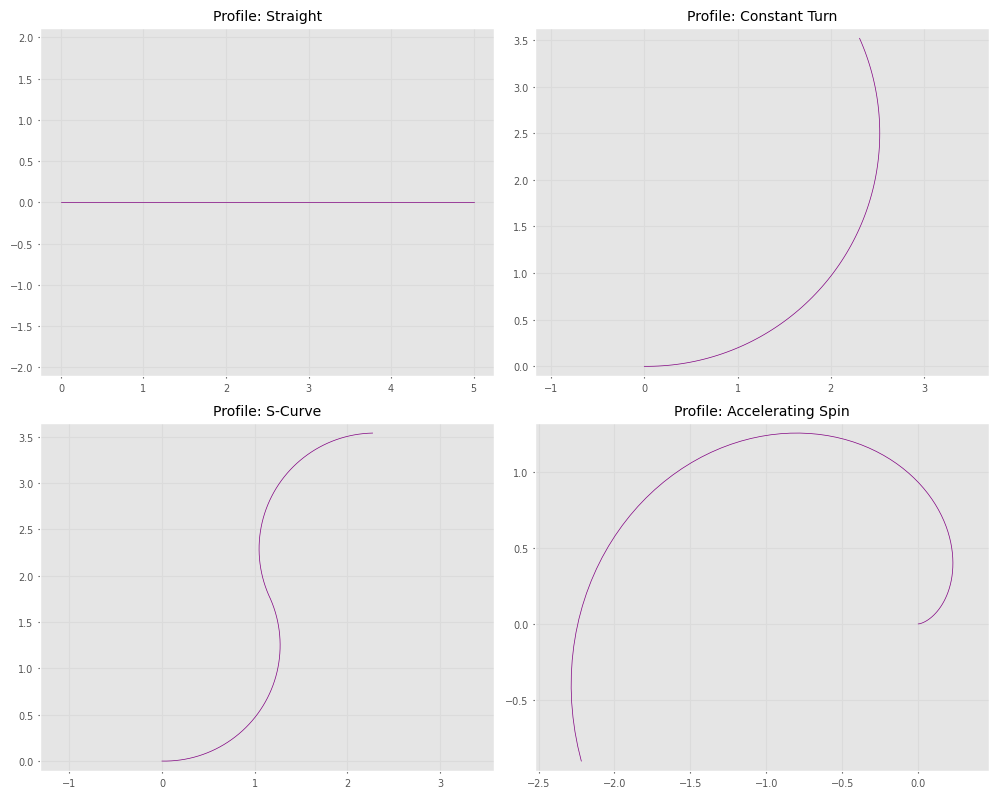

In [8]:
# Command Profiles (Example: Constant linear velocity, stepped turning profiles)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
profiles = [
    ("Straight", lambda t: 0.5, lambda t: 0.0),
    ("Constant Turn", lambda t: 0.5, lambda t: 0.2),
    ("S-Curve", lambda t: 0.5, lambda t: 0.4 if t < 5 else -0.4),
    ("Accelerating Spin", lambda t: 0.1 * t, lambda t: 0.5)
]

for idx, (name, v_f, w_f) in enumerate(profiles):
    xh, yh = simulate_unicycle(v_f, w_f)
    ax = axs[idx // 2, idx % 2]
    ax.plot(xh, yh, label=name, color='purple')
    ax.set_title(f"Profile: {name}")
    ax.grid(True)
    ax.axis('equal')

plt.tight_layout()
plt.show()

### Lab 7.8

In [9]:
R = 0.035  # Wheel radius (3.5 cm)
W = 0.15   # Wheel track baseline distance (15 cm)

def diff_drive_fk(phi_dot_left, phi_dot_right):
    # Calculate linear and angular velocities of the robot chassis
    v = (R / 2.0) * (phi_dot_right + phi_dot_left)
    w = (R / W) * (phi_dot_right - phi_dot_left)
    
    # Calculate turning radius (Instantaneous Center of Curvature)
    turning_radius = v / w if w != 0 else float('inf')
    return v, w, turning_radius

# Test run
v_c, w_c, radius = diff_drive_fk(phi_dot_left=10.0, phi_dot_right=12.0)
print(f"Chassis Motion Profile -> Linear: {v_c:.3f} m/s, Angular: {w_c:.3f} rad/s, Radius of Curvature: {radius:.3f} m")

Chassis Motion Profile -> Linear: 0.385 m/s, Angular: 0.467 rad/s, Radius of Curvature: 0.825 m


### Lab 7.9

In [10]:
# 1. Base transformation matrix relative to World origin (Positioned at x=1.5m, y=2.0m, rotated 45 degrees)
alpha = np.radians(45)
T_world_base = np.array([
    [np.cos(alpha), -np.sin(alpha), 0, 1.5],
    [np.sin(alpha),  np.cos(alpha), 0, 2.0],
    [0,              0,             1, 0.0],
    [0,              0,             0, 1.0]
])

# 2. Arm transformation matrix relative to Base (Using your 2R or Panda configuration)
# Let's mock a configuration where the arm extends 0.5m forward along its local X axis
T_base_tcp = np.eye(4)
T_base_tcp[0, 3] = 0.5  
T_base_tcp[2, 3] = 0.3  # Mounted 30cm up from chassis center

# 3. Combined Forward Kinematics
T_world_tcp = T_world_base @ T_base_tcp

print("--- Lab 7.9 Combined TCP Pose in World Frame ---")
print(T_world_tcp)
print(f"\nFinal TCP Position -> X: {T_world_tcp[0,3]:.3f}m, Y: {T_world_tcp[1,3]:.3f}m, Z: {T_world_tcp[2,3]:.3f}m")

--- Lab 7.9 Combined TCP Pose in World Frame ---
[[ 0.70710678 -0.70710678  0.          1.85355339]
 [ 0.70710678  0.70710678  0.          2.35355339]
 [ 0.          0.          1.          0.3       ]
 [ 0.          0.          0.          1.        ]]

Final TCP Position -> X: 1.854m, Y: 2.354m, Z: 0.300m
